### This notebook compute "VSS8. Establishment of the Water Resources Management Council in river basins" indicator for the 27 basins of IKI Project

Spanish: Establecimiento del Consejo de Gestión de Recursos Hídricos en cuencas

**Created:** 10/10/2025 by Serena Gilson (sgilson@rti.org)  
**Project #:** 0219481  
**Last modified:**
**Status:** Complete and loaded in SQLite database. 
**QA Status:** reviewed by  
**Original Script Stored at:** Research Triangle Institute\IKI Peru Project - General\Interno\AI2a_Metodologia\Indicadores\Vulnerabilidad
 
**Inputs:**   Shapefile of COMIDs and districts, Cuencas_seleccionadas_v2 excel with CHRC aprobado column, updated with information from Secretarias_Tecnicas_CRHC.xlsx (https://researchtriangleinstitute.sharepoint.com/sites/IKIPeruProject/_layouts/OneNote.aspx?id=%2Fsites%2FIKIPeruProject%2FSiteAssets%2FIKI%20Peru%20Project%20Notebook&wd=target%28A%20I.2a%20Metodolog%C3%ADa.one%7CE4F0A3E9-1807-4EEC-ACAF-990D5085BE29%2FVulnerabilidad%20-VSS%7C7A7EDE70-F96D-49D9-8A26-E99C2741A473%2F%29
onenote:https://researchtriangleinstitute.sharepoint.com/sites/IKIPeruProject/SiteAssets/IKI%20Peru%20Project%20Notebook/A%20I.2a%20Metodología.one#Vulnerabilidad%20-VSS&section-id={E4F0A3E9-1807-4EEC-ACAF-990D5085BE29}&page-id={7A7EDE70-F96D-49D9-8A26-E99C2741A473}&object-id={3514C385-1E76-0B57-3AB7-0AF6750FF041}&14)
 
la fuente es el portal de ANA: https://www.ana.gob.pe/nosotros/directorio/secretarias-tecnicas-consejos-recursos-hidricos

**Outputs:** 
 
**Assumptions:** Simplified index to just including a 0 (no tiene) and 1 (tiene) as we don't have information on women, afroperuanos, joventud for each of these consejos de cuenca. Assume those subbasins without data do not have a CGRH (i.e. NA is given 0) 
 
**Future work:** 
-Determine how to associate a value for subbasins that don't have watersheds associated. 
-add in function that removes accents from strings to pre-processing not required. 

-Determine how to handle NA vs 0 cases. 
 
**Notes:** 

In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
import sqlite3
import matplotlib.pyplot as plt

In [2]:
#SETTINGS

#user = 'jmayo'
#user= 'cpickering'
user = 'sgilson'
ScnID= 1 #Scenario ID -- 1: Baseline, 1981-2005, 2: Future, 2030, 3: Future: 2050
IndID= 408 #Indicator ID (Exposure = 2 + 0X where X is the Exposure Indicator number, Peligro= 1 +0x, VSB= 3 +0x, VSS= 4 +0x, VCA= 5 +0x)
db_path = fr'C:\Users\{user}\Research Triangle Institute\IKI Peru Project - General\Interno\AI2a_Metodologia\Indicadores\BD_RiesgoClimatico_IKI.db'

In [3]:
#INPUTS 

subbasins_shapefile = f'C:/Users/{user}/Research Triangle Institute/IKI Peru Project - General/Interno/AI2b_Modelacion/Grupos_Modelacion/GIS_WaterALLOC_General/Peru_AHD_with_districts.shp'
subbasins_gdf = gpd.read_file(subbasins_shapefile).to_crs('EPSG:32718')

#read in Excel with consejo de cuenca information
#NOTE: needed to remove all accents except ñ so that it matches up correctly with subbasins gdf 'Cuenca' column
#add in function that removes accents from strings to pre-processing not required. 
consejo_df = pd.read_excel(fr'C:\Users\{user}\Research Triangle Institute\IKI Peru Project - General\Interno\Cuencas_seleccionadas_v2.xlsx', sheet_name='Cuencas_seleccionadas', usecols=['Cuenca', 'CRHC Aprobado'], dtype={'Cuenca': str, 'CRHC Aprobado': str})


In [4]:
#FORMATTING THE DATAFRAME AND CALCULATING INDICATOR

#remove rows with NaN in 'CRHC Aprobado' column
consejo_df = consejo_df.dropna(subset=['CRHC Aprobado'])

#add another column to indicate whether CRHC is approved or not with 0 for 'Sin CRHC' and 1 for other
consejo_df['CRHC'] = np.where(consejo_df['CRHC Aprobado'] == 'Sin CRHC', 0, 1)

#merge with subbasins_gdf on 'Cuenca' and 'Cuenca' columns
subbasins_gdf = subbasins_gdf.merge(consejo_df[['Cuenca', 'CRHC']], left_on='Cuenca', right_on='Cuenca', how='left')

# Fill NaN values with 0 (no CRHC data means no CRHC approved)
subbasins_gdf['CRHC'] = subbasins_gdf['CRHC'].fillna(0)

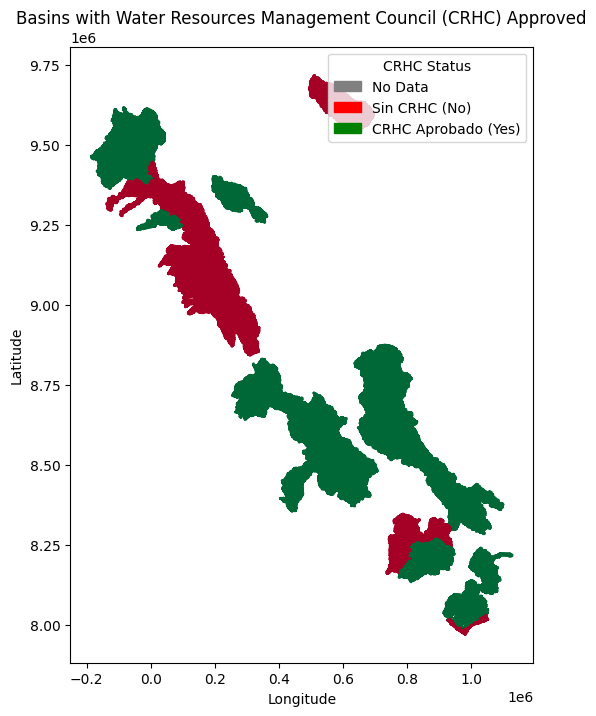

In [5]:
#PLOT RESULTS

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Plot CRHC with legend
fig, ax = plt.subplots(figsize=(10, 8))

# Fill NaN values with a placeholder value (e.g., -1) for plotting
subbasins_gdf['CRHC_plot'] = subbasins_gdf['CRHC'].fillna(-1)

# Plot with custom colors
subbasins_gdf.plot(column='CRHC_plot', ax=ax, legend=False, 
                   cmap='RdYlGn', edgecolor='face', linewidth=1.5, 
                   missing_kwds={'color': 'grey', 'edgecolor': 'grey', 'label': 'No Data'})

# Create custom legend
legend_labels = {-1: 'No Data', 0: 'Sin CRHC (No)', 1: 'CRHC Aprobado (Yes)'}
colors = {-1: 'grey', 0: 'red', 1: 'green'}

# Create patches for the legend
patches = [mpatches.Patch(color=colors[key], label=legend_labels[key]) 
           for key in sorted(legend_labels.keys())]

# Add legend
ax.legend(handles=patches, loc='upper right', title='CRHC Status')

plt.title('Basins with Water Resources Management Council (CRHC) Approved')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

SQLITE INSERT 

In [6]:
#Update relevant dataframe and value column from the calculations above for the specific indicator
insert_data= subbasins_gdf #COMID and Feauture_Count
value_column= 'CRHC'

In [7]:
# Connect to your SQLite database
conn = sqlite3.connect(db_path)
cursor = conn.cursor()

# Fixed IndID and ScnID (update above)

#For now I am commenting out the looping of scenarios as I imagine we might run just baseline scenarios for now.
# Define the mapping between scenario and DataFrame column
# scenario_columns = {
#     1: 'ACTUAL ANUAL',
#     2: '2030 ANUAL',
#     3: '2050 ANUAL'
# }

# Prepare list of rows to insert
rows_to_insert = []

#for scn_id, column_name in scenario_columns.items():
for _, row in insert_data.iterrows():
    comid = row['COMID']
    value = row[value_column]
    #normalized_value = None  # or compute something like: value / max_value #took out normalized value from the table for now
    rows_to_insert.append((ScnID, IndID, comid, value))

# Insert data into IndValues_Dyn
insert_query = """
INSERT OR REPLACE INTO IndValues_Dyn (ScnID, IndID, COMID, Value)
VALUES (?, ?, ?, ?);
"""


In [8]:
# Check for duplicates in the input dataframe before insert
df_check = pd.DataFrame(rows_to_insert, columns=['ScnID', 'IndID', 'COMID', 'Value'])
duplicates = df_check.duplicated(subset=['ScnID', 'IndID', 'COMID'])
print("Duplicates in rows_to_insert:", df_check[duplicates])

Duplicates in rows_to_insert: Empty DataFrame
Columns: [ScnID, IndID, COMID, Value]
Index: []


In [9]:
rows_to_insert

[(1, 408, 311153600, 1.0),
 (1, 408, 310832400, 1.0),
 (1, 408, 310825700, 1.0),
 (1, 408, 310282400, 1.0),
 (1, 408, 308754600, 1.0),
 (1, 408, 307736500, 0.0),
 (1, 408, 307078200, 0.0),
 (1, 408, 307183500, 0.0),
 (1, 408, 306538400, 1.0),
 (1, 408, 306599700, 1.0),
 (1, 408, 306319300, 0.0),
 (1, 408, 306030000, 0.0),
 (1, 408, 305746400, 1.0),
 (1, 408, 311953100, 1.0),
 (1, 408, 304273900, 0.0),
 (1, 408, 304281100, 0.0),
 (1, 408, 304281200, 0.0),
 (1, 408, 304379300, 0.0),
 (1, 408, 304274000, 0.0),
 (1, 408, 304313700, 0.0),
 (1, 408, 304306400, 0.0),
 (1, 408, 304327700, 0.0),
 (1, 408, 304313800, 0.0),
 (1, 408, 304306300, 0.0),
 (1, 408, 304321600, 0.0),
 (1, 408, 304321700, 0.0),
 (1, 408, 304339400, 0.0),
 (1, 408, 304335700, 0.0),
 (1, 408, 304343200, 0.0),
 (1, 408, 304343100, 0.0),
 (1, 408, 304335800, 0.0),
 (1, 408, 304343000, 0.0),
 (1, 408, 304330900, 0.0),
 (1, 408, 304352700, 0.0),
 (1, 408, 304421200, 0.0),
 (1, 408, 304403000, 0.0),
 (1, 408, 304352600, 0.0),
 

In [10]:
#Execute insert to SQLite Database
cursor.executemany(insert_query, rows_to_insert)
conn.commit()
conn.close()